In [2]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import batman
import emcee

C:\Users\yuvra\AppData\Roaming\Python\Python312\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
%matplotlib inline

In [27]:
search_result = lk.search_lightcurve("WASP-17", mission="TESS")
lc_collection = search_result[[0, 1, 3]].download_all()
crowdsap = []
for i in range(3):
    crowdsap.append(lc_collection[i].meta['CROWDSAP'])
crowdsap = np.mean(crowdsap)
print(crowdsap)

0.98809872


In [16]:
lc_list = []

for i, lc_sector in enumerate(lc_collection):
    clean = lc_sector.remove_nans()
    clean = clean.remove_outliers(sigma=7).flatten(window_length=901)
    lc_list.append(clean)

lc_list = lk.LightCurveCollection(lc_list)
lc = lc_list.stitch()

In [17]:
pg = lc.to_periodogram(method='bls', minimum_period=1, maximum_period=27, frequency_factor=150)

`period` contains 604370 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


In [18]:
pg.period_at_max_power

<Quantity 3.73548831 d>

In [19]:
lc_folded = lc.fold(period=pg.period_at_max_power, epoch_time=-2407.19882).bin(time_bin_size=0.005)

In [20]:
depth = 1 - np.min(lc_folded.flux.value)
rp_est = np.sqrt(depth)
print(rp_est)

0.11464263687173139


In [21]:
params = batman.TransitParams()
params.per = 3.735
params.t0 = 0
params.rp = rp_est
params.inc = 86.83
params.a = 7.03
params.w = 90
params.ecc = 0
params.u = [0.29, 0.31]
params.limb_dark = 'quadratic'

t = lc_folded.time.value
m = batman.TransitModel(params, t)

flux = m.light_curve(params)

In [28]:
def log_prob(theta):
    params.t0 = theta[0]
    params.rp = theta[1]
    
    m = batman.TransitModel(params, t)
    flux = m.light_curve(params)

    flux_diluted = crowdsap*flux + (1 - crowdsap)
    
    diff = lc_folded.flux.value - flux_diluted
    chi_squared = np.sum((diff**2)/(lc_folded.flux_err.value**2))

    return -0.5 * chi_squared

def log_prior(theta):
    t0, rp = theta

    if -2 < t0 < 2 and 0 < rp < 1:
        return 0.0
    return -np.inf

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    val = lp + log_prob(theta)
    return -np.inf if not np.isfinite(val) else val

In [36]:
walker_vector = np.full([32,2], [0, rp_est], float) + np.random.uniform(-0.01, 0.01, [32,2])

sampler = emcee.EnsembleSampler(32,2, log_probability)
sampler.run_mcmc(walker_vector, 1000)

-0.00326854520815658 +- 0.0012532938424050712
0.108121187862811 +- 0.0016034739706064101


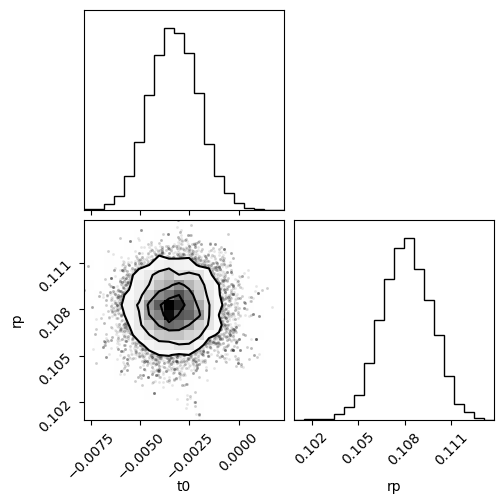

In [41]:
import corner
corner.corner(chain, labels=['t0', 'rp'])
plt.show()

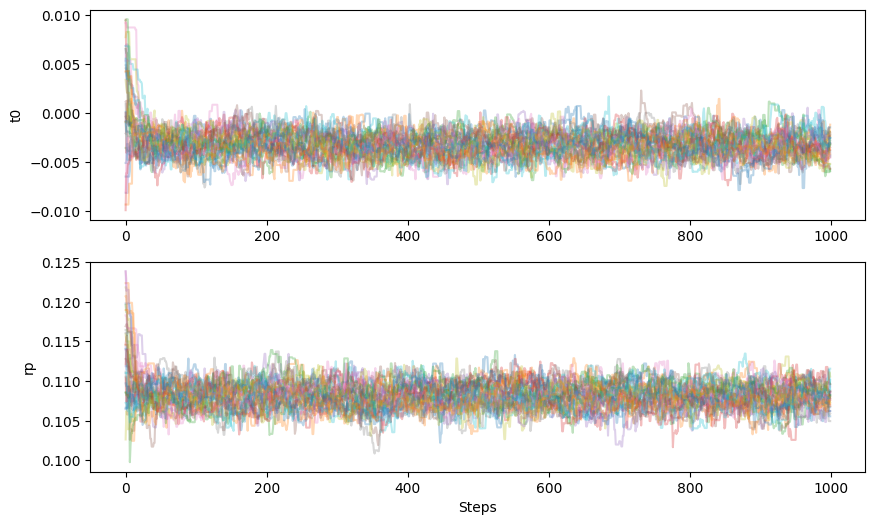

In [39]:
fig, axes = plt.subplots(2, figsize=(10,6))
samples = sampler.get_chain()
labels = ['t0', 'rp']
for i in range(2):
    axes[i].plot(samples[:,:,i],alpha=0.3)
    axes[i].set_ylabel(labels[i])
axes[-1].set_xlabel('Steps')
plt.show()

In [43]:
chain = sampler.get_chain(flat=True, discard=300)
mean_t0 = np.mean(chain[:,0])
mean_rp = np.mean(chain[:,1])
sd_t0 = np.std(chain[:,0])
sd_rp = np.std(chain[:,1])

print(f"t0  = {mean_t0:.6f} ± {sd_t0:.6f}  days")
print(f"Rp  = {mean_rp:.6f} ± {sd_rp:.6f}")

t0  = -0.003269 ± 0.001253  days
Rp  = 0.108121 ± 0.001603


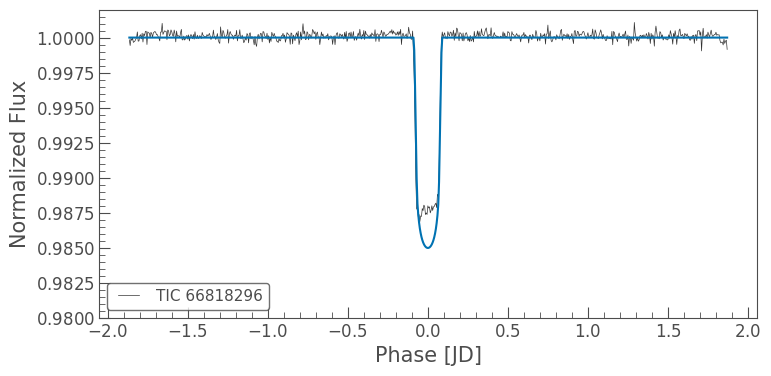

0.9868570658110963


In [37]:
ax = lc_folded.plot()
ax.set_ylim(0.98, 1.002)

ax.plot(t, flux)
plt.show()
print(np.min(lc_folded.flux.value))